# Saliency — executable peer-review notebook

Same engine as the live instrument. Data is pulled from this GitHub repository. Seeds are disclosed. Re-run all cells from the top.

Van Dijcke, D., Wright, A. L., & Polyak, M. (2023). Public response to government alerts saves lives during Russian invasion of Ukraine. *PNAS*, 120(18), e2220160120.

**We claim:** a GWT cycle with a hard ignition bar produces a delayed then decaying displacement pulse; habituation and calendar foils are separable; 21 interface checks pass on a city that is not Kyiv.

**We do not claim:** recovery of the original PNAS coefficients; a Simile 0.16 threshold; wartime 2022 density; fitted confidence intervals; that τ = 230 is independently measured.

Expected numbers (same seeds as the instrument): Mar–Apr **31.1 m**, May–Jun **6.7 m**, Jul–Sep **silent**, architecture **21/21**, pre-trend **0**.


## 0 · Setup

The engine lives in `saliency/`. If this notebook is opened on its own, the first cell installs the package from GitHub. Data lives in `data/` in this repo, or is fetched from GitHub raw URLs.


In [1]:
import sys
import subprocess
from pathlib import Path

REPO = "https://github.com/testing-crsscl/saliency-kyiv.git"

def ensure_engine() -> str:
    here = Path.cwd()
    for candidate in (here, here.parent):
        if (candidate / "saliency" / "__init__.py").exists():
            sys.path.insert(0, str(candidate))
            return f"local {candidate}"
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", f"git+{REPO}"])
    return "pip " + REPO

print("engine", ensure_engine())

from saliency.data import load_bundle, source_label, GITHUB_URL, RAW_BASE
from saliency.engine import (
    ACTIONS, DEFAULT_PARAMS, MINUTES, PERIODS,
    acoustic_saliency, acoustic_table, appraise_threat, build_env,
    make_population, mulberry32, run_architecture_tests,
    run_dual_regions, run_event_window, run_first_alert, run_period,
    stay_safe_saliency, typical_kyivan_appraisal, wvs_distributions,
    worked_example, synthetic_city,
)

print("GitHub", GITHUB_URL)
print("data  ", source_label())
print("raw   ", RAW_BASE)
bundle = load_bundle()
env = build_env(bundle["grid"])
print("grid  ", bundle["grid"]["n"], "×", bundle["grid"]["n"], "at", bundle["grid"]["cellM"], "m")
print("cells ", bundle["grid"]["occupied"], "occupied,", bundle["grid"]["buildings"], "OSM footprints")
print("people", round(bundle["grid"].get("popOnOccupied") or 0), "WorldPop 2020 constrained")
print("WVS   n =", bundle["wvs"]["nKyiv"], "Kyiv city (UA-30)")
print("alerts", bundle["sirens"]["nVanDijckeWindow"], "in", bundle["sirens"]["window"])
print("params", DEFAULT_PARAMS)
print("rng   mulberry32 — JS unsigned >>>, signed |0, Math.imul")


engine local /workspace/review
GitHub https://github.com/testing-crsscl/saliency-kyiv
data   local checkout (/workspace/review/data)
raw    https://raw.githubusercontent.com/testing-crsscl/saliency-kyiv/main/data
grid   174 × 174 at 250.0 m
cells  7146 occupied, 114005 OSM footprints
people 3338494 WorldPop 2020 constrained
WVS   n = 123 Kyiv city (UA-30)
alerts 407 in 2022-03-15/2022-09-30
params {'idleThreshold': 0.3, 'acousticBase': 0.93, 'habituationTau': 230, 'calendarTauDays': 201}
rng   mulberry32 — JS unsigned >>>, signed |0, Math.imul


## 1 · Provenance

Every input is classified. *Measured* means a file in `data/`. *Reconstructed* means digitised from a published figure. *Transferred* means a named study on a different population. *Calibrated* means chosen so a reconstructed ratio is recoverable.


In [2]:
print("alerts     MEASURED     ", bundle["sirens"]["source"][:90])
print("grid/OSM   MEASURED     ", bundle["grid"]["source"][:90] if isinstance(bundle["grid"].get("source"), str) else "OSM footprints + SRTM")
print("WorldPop   MEASURED     ", bundle["grid"].get("popSource") or "WorldPop 2020 constrained 100 m")
print("WVS        MEASURED     ", bundle["wvs"]["source"][:90] if isinstance(bundle["wvs"].get("source"), str) else "WVS Wave 7 UA-30")
print("Van Dijcke RECONSTRUCTED", bundle["vd"]["source"][:90])
print("τ = 230    CALIBRATED   to reconstructed Mar–Apr / Jul–Sep peak ratio")
print("appraisal  ASSUMED      structural WVS weights (no shelter-seeking item)")
print("walk/lag   TRANSFERRED  Bohannon 1997; PADM / Purser log-normal")
print("idle bar   CATALINA     0.30 (not Simile 0.16)")
print("acoustic   NAMED        s0 = 0.93")


alerts     MEASURED      Vadimkin / eTryvoga official_data_en.csv. Kyiv City, oblast level. Overlaps merged.
grid/OSM   MEASURED      OSM extract download.openstreetmap.fr/europe/ukraine/kiev.osm.pbf (ODbL); terrain AWS Terr
WorldPop   MEASURED      WorldPop and DLR (2022). Gridded population estimates for Ukraine using UN COD-PS estimates 2020, version 2.0. Constrained 100 m, CC BY. https://data.worldpop.org/repo/wopr/UKR/v2/constrained/
WVS        MEASURED      WVS Wave 7 Ukraine 2020, v5.1 (Haerpfer et al.). Fielded before the invasion. Kyiv city = 
Van Dijcke RECONSTRUCTED Reconstructed from published PNAS 120(18) event-study figures (y-axis metres, window −10..
τ = 230    CALIBRATED   to reconstructed Mar–Apr / Jul–Sep peak ratio
appraisal  ASSUMED      structural WVS weights (no shelter-seeking item)
walk/lag   TRANSFERRED  Bohannon 1997; PADM / Purser log-normal
idle bar   CATALINA     0.30 (not Simile 0.16)
acoustic   NAMED        s0 = 0.93


## 2 · Lattice — WorldPop mass on OSM buildings


occupied 7146 mass total 3338494
elev 82 – 209 m SRTM
shelters 1009 metro 195
placement: WorldPop mass, not WVS PSU coordinates (architecture T21)


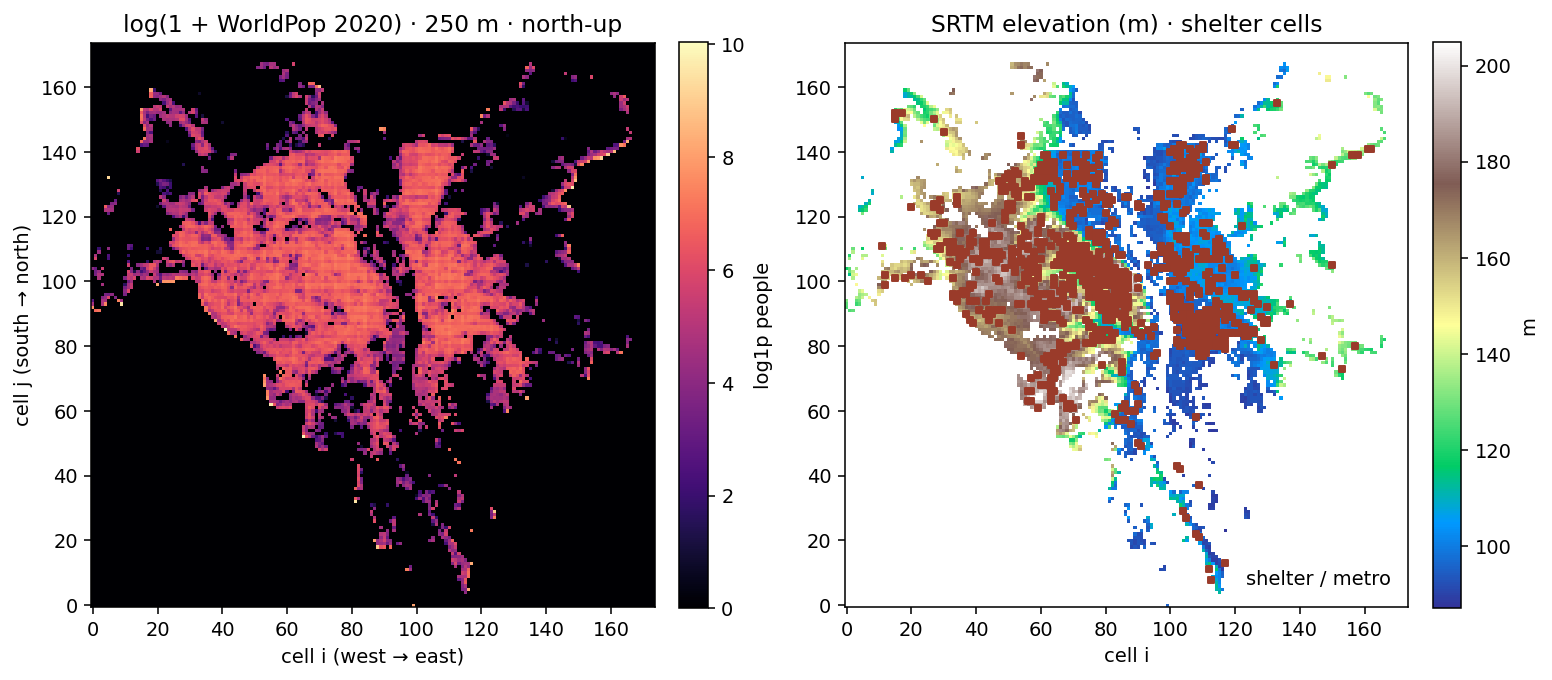

In [3]:
import numpy as np
import matplotlib.pyplot as plt

n = env["n"]
mass = np.zeros((n, n))
elev = np.full((n, n), np.nan)
shelter = np.zeros((n, n))
for cell, m in zip(env["cells"], env["mass"]):
    mass[cell["j"], cell["i"]] = m
    elev[cell["j"], cell["i"]] = cell.get("e") or np.nan
    if cell.get("shelter"):
        shelter[cell["j"], cell["i"]] = 1

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.2))
im0 = axes[0].imshow(np.log1p(mass), origin="lower", cmap="magma", interpolation="nearest")
axes[0].set_title("log(1 + WorldPop 2020) · 250 m · north-up")
axes[0].set_xlabel("cell i (west → east)")
axes[0].set_ylabel("cell j (south → north)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="log1p people")
im1 = axes[1].imshow(elev, origin="lower", cmap="terrain", interpolation="nearest")
yy, xx = np.where(shelter > 0)
axes[1].scatter(xx, yy, s=8, c="#9a3b2a", marker="s", label="shelter / metro")
axes[1].set_title("SRTM elevation (m) · shelter cells")
axes[1].set_xlabel("cell i")
axes[1].legend(frameon=False, loc="lower right")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="m")
fig.tight_layout()
plt.show()
print("occupied", len(env["cells"]), "mass total", round(env["massTotal"]))
print("elev", bundle["grid"].get("elevMin"), "–", bundle["grid"].get("elevMax"), "m SRTM")
print("shelters", bundle["grid"]["shelterCells"], "metro", bundle["grid"]["metroCells"])
print("placement: WorldPop mass, not WVS PSU coordinates (architecture T21)")


## 3 · Beliefs — resampled WVS Wave 7 Kyiv respondents (n = 123)


scepticism Kyiv 0.608 national 0.559
typical threat 0.48 Stay_Safe(0) 0.64 Stay_Safe(406) 0.109 defiance gate 0.32
female share 0.588 employed 0.664


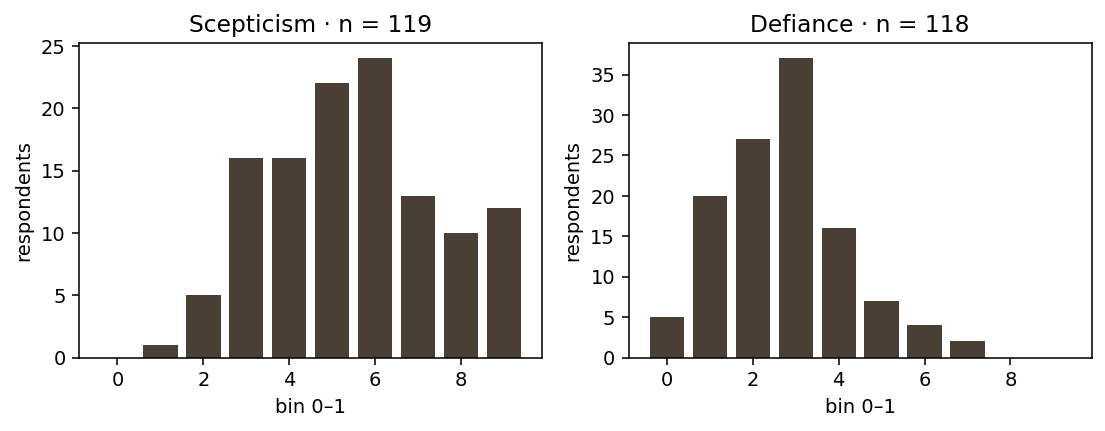

In [4]:
wvs = wvs_distributions(bundle["wvs"]["pool"])
kyiv = typical_kyivan_appraisal(bundle["wvs"])
print("scepticism Kyiv", round(bundle["wvs"]["scepticismKyiv"], 3),
      "national", round(bundle["wvs"]["scepticismNational"], 3))
print("typical threat", round(kyiv["threat"], 3),
      "Stay_Safe(0)", round(kyiv["stay0"], 3),
      "Stay_Safe(406)", round(kyiv["stay406"], 3),
      "defiance gate", round(kyiv["defianceGate"], 3))
print("female share", round(wvs["femaleShare"], 3), "employed", round(wvs["employedShare"], 3))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
for ax, key, title in ((axes[0], "scepticism", "Scepticism"), (axes[1], "defiance", "Defiance")):
    ax.bar(range(10), wvs[key]["counts"], color="#4a3f35")
    ax.set_title(f"{title} · n = {wvs[key]['n']}")
    ax.set_xlabel("bin 0–1")
    ax.set_ylabel("respondents")
fig.tight_layout()
plt.show()


## 4 · Sense — acoustic saliency habituates

$$s(n) = 0.93\,\exp(-n/230)$$

Idle bar 0.30. Committed 0.75. Asleep 0.90. After ~360 alerts the idle population is silent. That is a real prediction, and where the reconstructed late-season pulse still sits above zero.


     n   acoustic     idle  committed   asleep
     0      0.930     True       True     True
    40      0.782     True       True    False
   100      0.602     True      False    False
   175      0.435     True      False    False
   220      0.357     True      False    False
   230      0.342     True      False    False
   360      0.194    False      False    False
   406      0.159    False      False    False


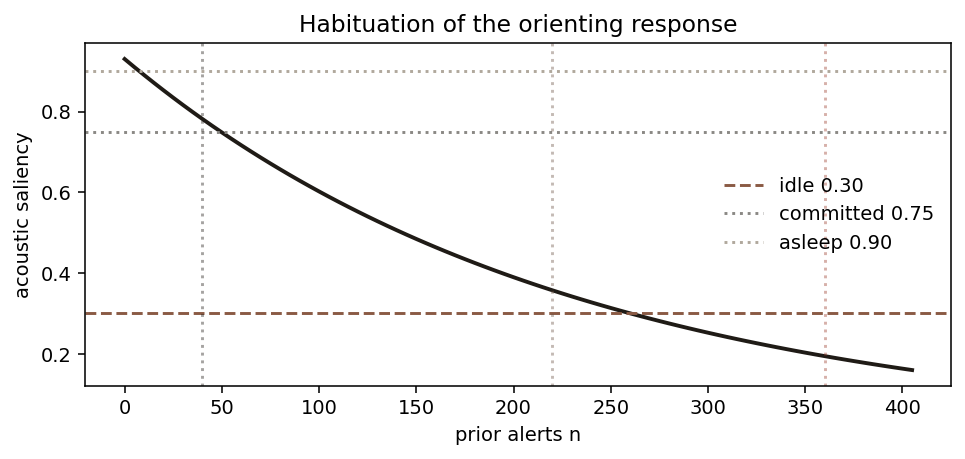

In [5]:
rows = acoustic_table()
print(f"{'n':>6} {'acoustic':>10} {'idle':>8} {'committed':>10} {'asleep':>8}")
for r in rows:
    print(f"{r['n']:6d} {r['acoustic']:10.3f} {str(r['ignitesIdle']):>8} {str(r['ignitesCommitted']):>10} {str(r['ignitesAsleep']):>8}")

xs = list(range(0, 410, 5))
ys = [acoustic_saliency(n) for n in xs]
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(xs, ys, color="#1f1b16", lw=2)
ax.axhline(0.30, color="#8a5a44", ls="--", label="idle 0.30")
ax.axhline(0.75, color="#8a8884", ls=":", label="committed 0.75")
ax.axhline(0.90, color="#b0a89c", ls=":", label="asleep 0.90")
ax.axvline(40, color="#1f1b16", ls=":", alpha=0.4)
ax.axvline(220, color="#6b5344", ls=":", alpha=0.4)
ax.axvline(360, color="#9a3b2a", ls=":", alpha=0.4)
ax.set_xlabel("prior alerts n")
ax.set_ylabel("acoustic saliency")
ax.set_title("Habituation of the orienting response")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 5 · Workspace cycle — twelve named functions

Unconscious processors run in parallel. A coalition that clears the attention bar ignites and is broadcast. Sub-threshold content is **absent**, not deprioritised.

```
perception → selection → inhibition/ignition → workspace
         → desire/intention deletion
         → appraisal + Stay_Safe + defiance gate
         → means-end → deliberation → focus
         → motor gate (P1) → plan execution
```

P1: the motor gate is closed for every t < 0. That is why pre-trend displacement is identically 0.


In [6]:
alert0 = bundle["sirens"]["windowAlerts"][0]
ex = worked_example(env, bundle["wvs"]["pool"], alert0["n"], alert0.get("hour", 16), alert0.get("wd", 2), 7)
a = ex["agent"]
print(f"agent  {a['age']:.0f} {a['sex']}  routine {a['routine']}  cell ({a['i']},{a['j']})")
print(f"sc {a['scepticism']:.2f}  df {a['defiance']:.2f}  acoustic {ex['acoustic']:.3f}  threat {ex['threat']:.3f}")
print(f"Stay_Safe {ex['stay']:.3f}  gate {ex['defianceGate']:.3f}  lag {a['decisionLagMin']} min  speed {a['walkSpeedMpm']:.0f} m/min")
for label, tr in (("t = -1  siren off", ex["pre"]), ("t =  0  siren on, lag blocks", ex["onset"]), (f"t = {ex['afterLag']['lag']}  lag elapsed", ex["afterLag"])):
    print(f"{label:32} heard={tr['heard']} ignited={tr['ignited']} defied={tr['defied']} {tr['action']:18} {tr['metres']:.1f} m")
print("P1: metres at t<0 must be 0 —", ex["pre"]["metres"])


agent  28 Female  routine asleep  cell (79,92)
sc 0.89  df 0.55  acoustic 0.930  threat 0.220
Stay_Safe 0.495  gate 0.604  lag 3 min  speed 73 m/min
t = -1  siren off                heard=False ignited=False defied=False continue           0.0 m
t =  0  siren on, lag blocks     heard=True ignited=True defied=True continue           0.0 m
t = 3  lag elapsed               heard=True ignited=True defied=True continue           0.0 m
P1: metres at t<0 must be 0 — 0


## 6 · Architecture checks — a city that is not Kyiv (must be 21/21)


In [7]:
tests = run_architecture_tests()
n_ok = sum(1 for t in tests if t["ok"])
print(f"{n_ok}/{len(tests)} pass")
assert n_ok == 21, tests
for t in tests:
    mark = "PASS" if t["ok"] else "FAIL"
    print(f"{mark:4} {t['id']:4} {t['name']:55} {t['detail'][:88]}")


21/21 pass
PASS P1   No pre-trend possible                                   max displacement t<0 is 0.0000 m (must be 0 at every point in parameter space)
PASS P2   Focused attention threshold floor of 0.50               attention = sal + (1−sal)/2 ≥ 0.5 for every sal in [0,1). CATALINA arithmetic, not a cho
PASS T03  Attention formula                                       committed 0.50 → 0.75; asleep 0.80 → 0.90
PASS T04  Idle thresholds equal                                   Unfocused: saliency threshold = attention threshold = idle default
PASS T05  Sub-threshold stimulus never enters the workspace       A 0.40 siren against a 0.75 bar is invisible — not deprioritised, absent. GWT ignition f
PASS T06  No one hears the siren before t=0                       heard[t<0] ≡ 0
PASS T07  Nobody walks at t=0 (own lag ≥ 1)                       displacement at t=0 is 0.0. Lags are log-normal with a floor of 1 min.
PASS T08  Synthetic 12×12 city is occupied                        80 occupi

## 7 · Event study — first window alert vs reconstructed Van Dijcke

Shape MSE compares max-normalised curves. Level MSE compares metres to metres. The PNAS series is a distance **sum** over a phone panel, so levels are not a replication target.

Seed 21, N = 140 — the same call the instrument makes.


sim peak 34.4 m at t = 4
VD  peak 1491.5 m
shape MSE 0.054 level MSE 480953.0
pre-trend max 0.0 (must be 0)
asleep 10 committed 58 idle 72
mean walk 81.5 m/min  mean lag 3.8 min


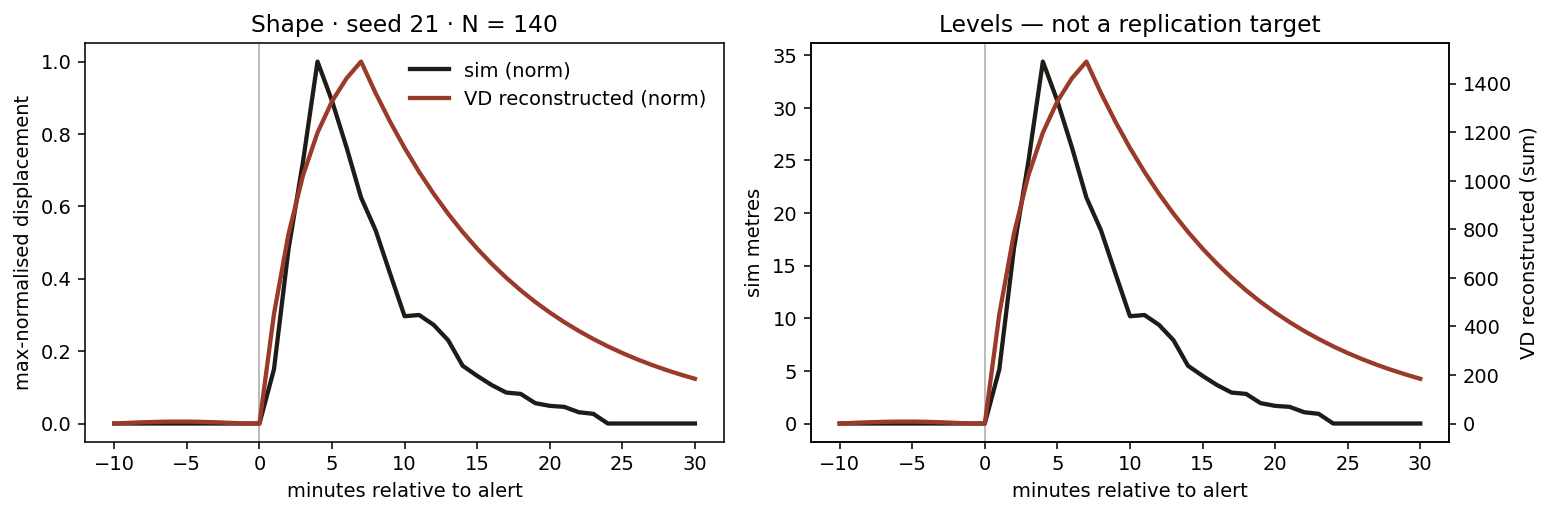

In [8]:
first = run_first_alert(env, bundle["wvs"]["pool"], alert0, bundle["vd"], 140, 21)
sim = first["result"]["displacement"]
vd = bundle["vd"]["overall"]
print("sim peak", round(first["result"]["peakMetres"], 2), "m at t =", first["result"]["peakMinute"])
print("VD  peak", round(first["vdPeak"], 1), "m")
print("shape MSE", round(first["shapeMse"], 3), "level MSE", round(first["levelMse"], 0))
print("pre-trend max", first["result"]["preTrendMax"], "(must be 0)")
assert first["result"]["preTrendMax"] == 0

smax = max(sim) or 1
vmax = max(vd) or 1
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8))
axes[0].axvline(0, color="#bbb", lw=1)
axes[0].plot(MINUTES, [v / smax for v in sim], color="#1f1b16", lw=2.2, label="sim (norm)")
axes[0].plot(MINUTES, [v / vmax for v in vd], color="#9a3b2a", lw=2.2, label="VD reconstructed (norm)")
axes[0].set_xlabel("minutes relative to alert")
axes[0].set_ylabel("max-normalised displacement")
axes[0].set_title("Shape · seed 21 · N = 140")
axes[0].legend(frameon=False)
axes[1].axvline(0, color="#bbb", lw=1)
axes[1].plot(MINUTES, sim, color="#1f1b16", lw=2.2, label="sim, mean m")
ax2 = axes[1].twinx()
ax2.plot(MINUTES, vd, color="#9a3b2a", lw=2.2, label="VD reconstructed")
axes[1].set_xlabel("minutes relative to alert")
axes[1].set_ylabel("sim metres")
ax2.set_ylabel("VD reconstructed (sum)")
axes[1].set_title("Levels — not a replication target")
fig.tight_layout()
plt.show()
print("asleep", first["result"]["nAsleep"], "committed", first["result"]["nCommitted"], "idle", first["result"]["nIdle"])
print("mean walk", round(first["result"]["meanWalk"], 1), "m/min  mean lag", round(first["result"]["meanLag"], 1), "min")


## 8 · What the population is doing — action mix and workspace


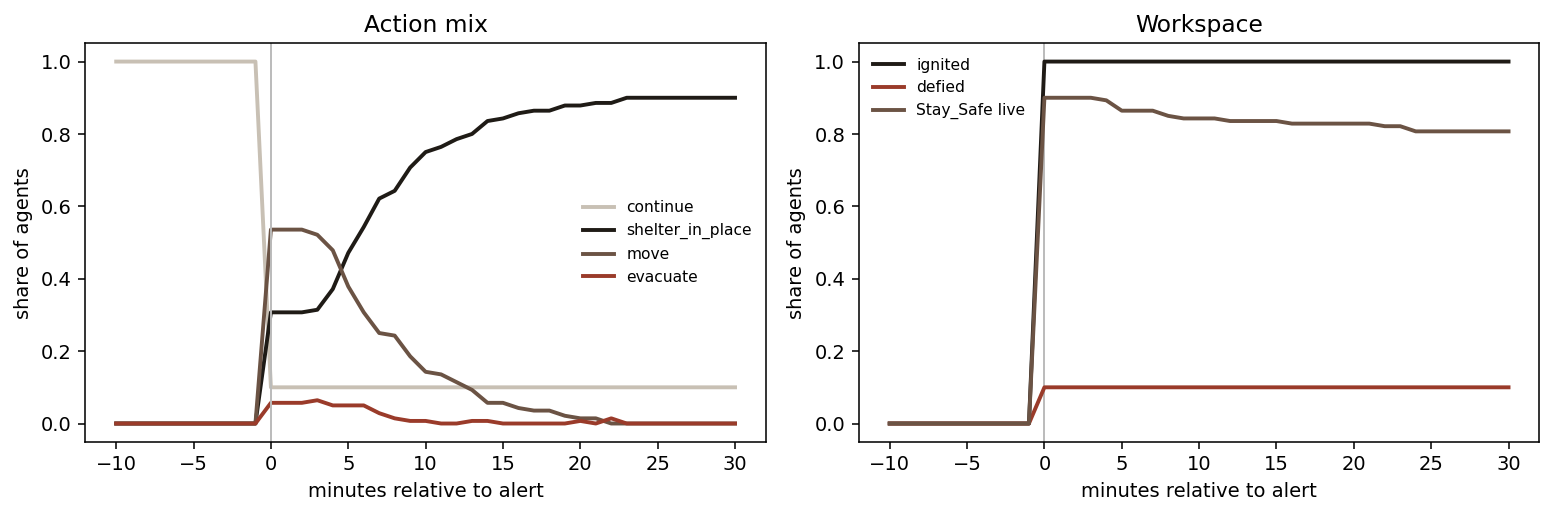

In [9]:
actions = first["result"]["actions"]
gw = first["result"]["gw"]
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8))
palette = {
    "continue": "#c8c0b4",
    "shelter_in_place": "#1f1b16",
    "move": "#6b5344",
    "evacuate": "#9a3b2a",
}
for key in ACTIONS:
    axes[0].plot(MINUTES, [row[key] for row in actions], color=palette[key], lw=2, label=key)
axes[0].axvline(0, color="#bbb", lw=1)
axes[0].set_xlabel("minutes relative to alert")
axes[0].set_ylabel("share of agents")
axes[0].set_title("Action mix")
axes[0].legend(frameon=False, fontsize=8)
axes[1].axvline(0, color="#bbb", lw=1)
axes[1].plot(MINUTES, [g["ignited"] for g in gw], color="#1f1b16", lw=2, label="ignited")
axes[1].plot(MINUTES, [g["defied"] for g in gw], color="#9a3b2a", lw=2, label="defied")
axes[1].plot(MINUTES, [g["staySafe"] for g in gw], color="#6b5344", lw=2, label="Stay_Safe live")
axes[1].set_xlabel("minutes relative to alert")
axes[1].set_ylabel("share of agents")
axes[1].set_title("Workspace")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## 9 · Three periods — the pulse decays, then goes silent


period         n  acoustic        sim       VD    shape
Mar–Apr       40     0.782     31.1 m     2100    0.056
May–Jun      220     0.357      6.7 m     1303    0.110
Jul–Sep      360     0.194     silent      733    0.258


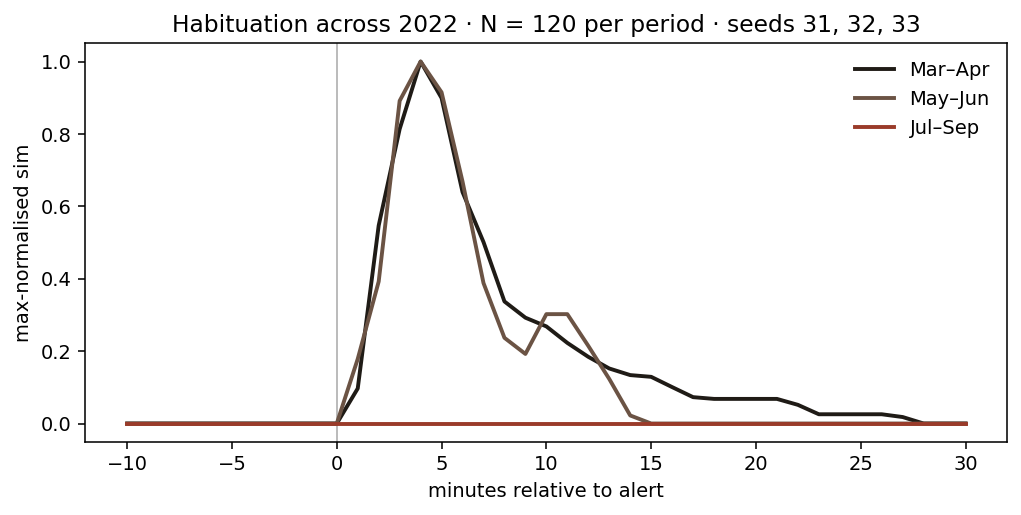

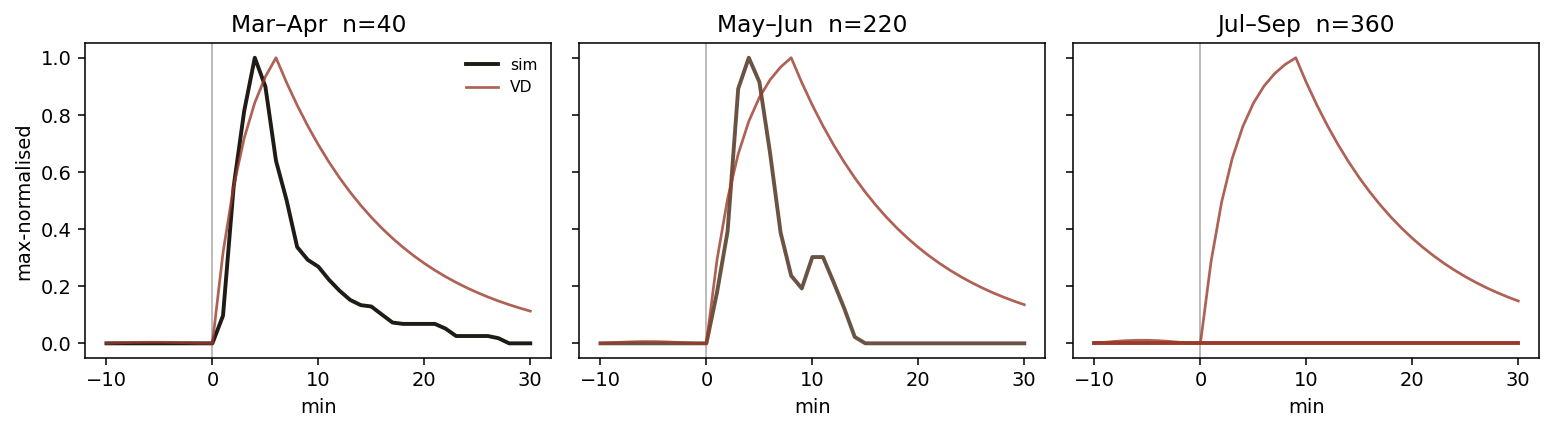

In [10]:
periods = [run_period(env, bundle["wvs"]["pool"], bundle["sirens"]["windowAlerts"], bundle["vd"], p, 120, 31 + i)
           for i, p in enumerate(PERIODS)]
print(f"{'period':10} {'n':>5} {'acoustic':>9} {'sim':>10} {'VD':>8} {'shape':>8}")
for r in periods:
    sims = "silent" if r["silent"] else f"{r['peakSim']:.1f} m"
    print(f"{r['label']:10} {r['exposure']:5d} {r['acoustic']:9.3f} {sims:>10} {r['peakVd']:8.0f} {r['shapeMse']:8.3f}")

fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.axvline(0, color="#bbb", lw=1)
colors = ["#1f1b16", "#6b5344", "#9a3b2a"]
for r, c in zip(periods, colors):
    m = max(r["displacement"]) or 1
    ax.plot(MINUTES, [v / m for v in r["displacement"]], color=c, lw=2, label=r["label"])
ax.set_xlabel("minutes relative to alert")
ax.set_ylabel("max-normalised sim")
ax.set_title("Habituation across 2022 · N = 120 per period · seeds 31, 32, 33")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.2), sharey=True)
for ax, r, c in zip(axes, periods, colors):
    sm = max(r["displacement"]) or 1
    vm = max(r["vd"]) or 1
    ax.axvline(0, color="#bbb", lw=1)
    ax.plot(MINUTES, [v / sm for v in r["displacement"]], color=c, lw=2, label="sim")
    ax.plot(MINUTES, [v / vm for v in r["vd"]], color="#9a3b2a", lw=1.4, alpha=0.8, label="VD")
    ax.set_title(f"{r['label']}  n={r['exposure']}")
    ax.set_xlabel("min")
axes[0].set_ylabel("max-normalised")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## 10 · Identifying design — two regions, two foils

A decaying pulse over 2022 does not identify habituation. Calendar time produces the same qualitative fact. Split a synthetic city: A heard 40 alerts, B heard 160, same date.

- **Habituation foil** — acoustic saliency uses each region's own n. A must out-move B.
- **Calendar foil** — same date-constant for both. A and B must match.


habituation A/B 55.6 15.6 ratio 3.56
calendar    A/B 27.9 19.0 ratio 1.47


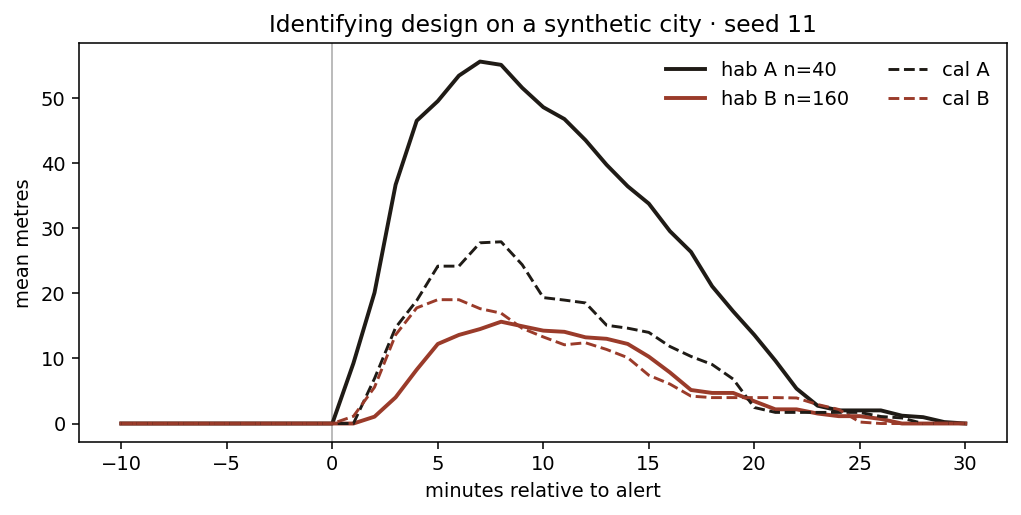

In [11]:
dual = run_dual_regions(build_env(synthetic_city(12)), bundle["wvs"]["pool"], 80, DEFAULT_PARAMS, 120, 40, 160, 11)
print("habituation A/B", round(dual["habituation"]["a"]["peakMetres"], 1),
      round(dual["habituation"]["b"]["peakMetres"], 1),
      "ratio", round(dual["habituation"]["ratio"], 2))
print("calendar    A/B", round(dual["calendar"]["a"]["peakMetres"], 1),
      round(dual["calendar"]["b"]["peakMetres"], 1),
      "ratio", round(dual["calendar"]["ratio"], 2))

fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.axvline(0, color="#bbb", lw=1)
ax.plot(MINUTES, dual["habituation"]["a"]["displacement"], color="#1f1b16", lw=2, label="hab A n=40")
ax.plot(MINUTES, dual["habituation"]["b"]["displacement"], color="#9a3b2a", lw=2, label="hab B n=160")
ax.plot(MINUTES, dual["calendar"]["a"]["displacement"], color="#1f1b16", lw=1.5, ls="--", label="cal A")
ax.plot(MINUTES, dual["calendar"]["b"]["displacement"], color="#9a3b2a", lw=1.5, ls="--", label="cal B")
ax.set_xlabel("minutes relative to alert")
ax.set_ylabel("mean metres")
ax.set_title("Identifying design on a synthetic city · seed 11")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()


## 11 · Verdict

Architecture is the claim most nearly earned (21/21, including P1: nothing moves before t = 0). Identification holds in the model's own world. Shape against a reconstruction is a visual rhyme in the first months. **Levels fail** — tens of metres vs thousands — because the PNAS series is a distance sum. Late-season silence against a still-positive reconstructed pulse is a real miss. Confidence is unfitted. Not policy-ready.

### What would falsify this

- Original coefficients with a non-zero pre-trend at t < 0
- A large late-season pulse after ~400 alerts if the idle bar is still 0.30
- Equal responses across a 4× exposure gap on the same date
- 2022 night locations that reject 2020 WorldPop
- A WVS shelter-seeking item that contradicts the structural weights


In [12]:
print("engine   saliency.engine  (Python port of src/sim/*.ts)")
print("data    ", GITHUB_URL)
print("checks  ", f"{n_ok}/{len(tests)}")
print("P1      ", first["result"]["preTrendMax"])
print("first   ", round(first["result"]["peakMetres"], 1), "m  shape", round(first["shapeMse"], 3))
print("Mar-Apr ", round(periods[0]["peakSim"], 1), "m  shape", round(periods[0]["shapeMse"], 3))
print("May-Jun ", round(periods[1]["peakSim"], 1), "m  shape", round(periods[1]["shapeMse"], 3))
print("Jul-Sep ", "silent" if periods[2]["silent"] else round(periods[2]["peakSim"], 1), "  shape", round(periods[2]["shapeMse"], 3))
print("done.")


engine   saliency.engine  (Python port of src/sim/*.ts)
data     https://github.com/testing-crsscl/saliency-kyiv
checks   21/21
P1       0.0
first    34.4 m  shape 0.054
Mar-Apr  31.1 m  shape 0.056
May-Jun  6.7 m  shape 0.11
Jul-Sep  silent   shape 0.258
done.
